In [157]:
import pandas as pd


In [158]:
df = pd.read_csv('/content/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [160]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [161]:
df.duplicated().sum()

0

In [162]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [163]:
len(df.Ticket.unique())

681

In [164]:
## Notes

# missing values
# 1) Age 714/891 -> 891-714 missing values
# 2) Cabin 204/891 -> 891-204 missing values
# 3) Embarked 889/891 -> 891-889 missing values

# There are no duplicated values
# Features that can be dropped: PassengerID, Name, Ticket


In [165]:
numerical_df = df.select_dtypes(include='number')
numerical_df = numerical_df [['Age','Fare']]
numerical_df.head(1)

,Age,Fare
0,22.0,7.25


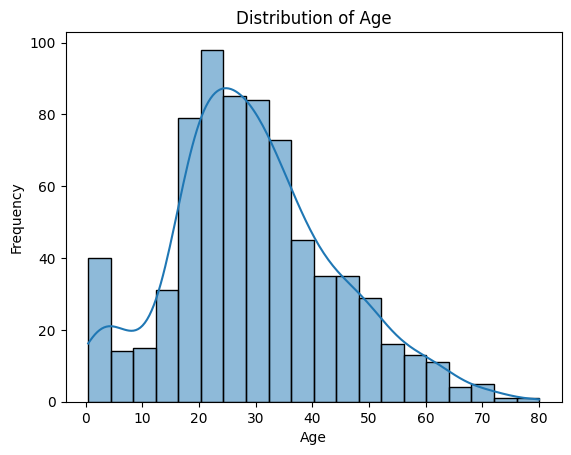

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Age'], bins=20, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

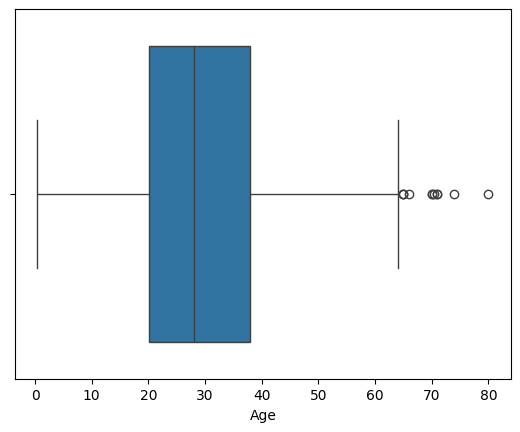

In [167]:
sns.boxplot(x=df['Age'])
plt.show()

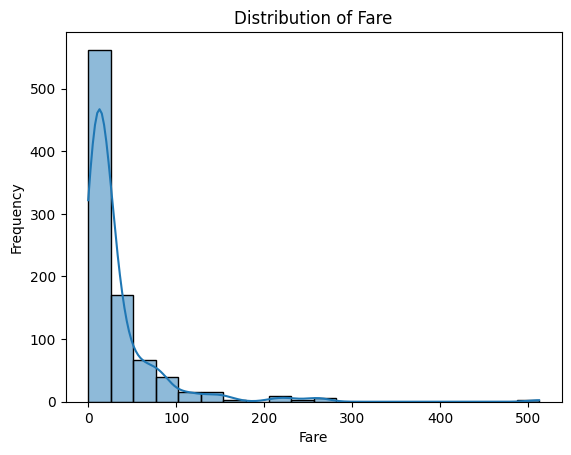

In [168]:
# For Fare
sns.histplot(df['Fare'], bins=20, kde=True)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Distribution of Fare')
plt.show()

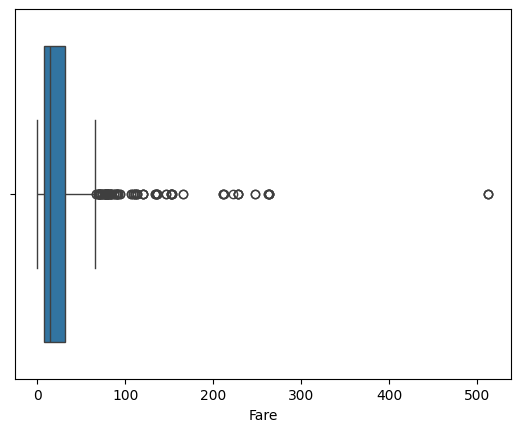

In [169]:
sns.boxplot(x=df['Fare'])
plt.show()

In [170]:
correlation = df['Age'].corr(df['Fare'])
correlation

0.0960666917690389

In [171]:
# Numerical analysis
# Age having values less than 1 may be a problem
# about 7 outliers whome ages are more than 60
# Fare feature is skewed to the right, so there are some outliers

In [172]:
categorical_df = df.select_dtypes(include=['object', 'category'])
categorical_df['SibSp'] = df['SibSp']
categorical_df['Parch'] = df['Parch']
categorical_df['Pclass'] = df['Pclass']
categorical_df = categorical_df[["Sex","Cabin", "Embarked","SibSp","Parch","Pclass"]]
categorical_df

,Sex,Cabin,Embarked,SibSp,Parch,Pclass
0,male,NaN,S,1,0,3
1,female,C85,C,1,0,1
2,female,NaN,S,0,0,3
3,female,C123,S,1,0,1
4,male,NaN,S,0,0,3
...,...,...,...,...,...,...
886,male,NaN,S,0,0,2
887,female,B42,S,0,0,1
888,female,NaN,S,1,2,3
889,male,C148,C,0,0,1


In [173]:
for column in categorical_df.columns:
    print(f"Unique values in column '{column}':")
    print(categorical_df[column].value_counts())
    print()

Unique values in column 'Sex':
Sex
male      577
female    314
Name: count, dtype: int64

Unique values in column 'Cabin':
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

Unique values in column 'Embarked':
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Unique values in column 'SibSp':
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Unique values in column 'Parch':
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Unique values in column 'Pclass':
Pclass
3    491
1    216
2    184
Name: count, dtype: int64



In [174]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [175]:
# Parch and SibSp -> biased towrds 0

In [176]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [177]:
df.drop(columns=['Cabin'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [178]:
#Split the data before any data preprocessing to prevent any data leakage...

from sklearn.model_selection import train_test_split



train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_median_age = train_df['Age'].median()
train_median_Fare = train_df['Fare'].median()

train_df['Age'] = train_df['Age'].fillna(train_median_age)
train_df['Fare'] = train_df['Fare'].fillna(train_median_Fare)

test_median_age = test_df['Age'].median()
test_median_Fare = test_df['Fare'].median()

test_df['Age'] = test_df['Age'].fillna(test_median_age)
test_df['Fare'] = test_df['Fare'].fillna(test_median_Fare)




In [179]:
#For categorical data

train_mode_Embarked = train_df['Embarked'].mode()[0]
test_mode_Embarked = test_df['Embarked'].mode()[0]

train_df['Embarked'] = train_df['Embarked'].fillna(train_mode_Embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(test_mode_Embarked)



In [180]:
train_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [181]:
# Pclass	SibSp	Parch -> label encoding
# Sex Embarked -> one hot encoding

In [182]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = ['Pclass', 'SibSp', 'Parch']

for col in label_cols:
    le.fit(train_df[col])
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

onehot_cols = ['Sex', 'Embarked']

train_df_onehot = pd.get_dummies(train_df, columns=onehot_cols)
test_df_onehot = pd.get_dummies(test_df, columns=onehot_cols)

In [183]:
train_df_onehot.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,0,0,45.5,0,0,28.5000,False,True,False,False,True
733,0,1,23.0,0,0,13.0000,False,True,False,False,True
382,0,2,32.0,0,0,7.9250,False,True,False,False,True
704,0,2,26.0,1,0,7.8542,False,True,False,False,True
813,0,2,6.0,4,2,31.2750,True,False,False,False,True


In [184]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


scale_cols = ['Age', 'Fare']

scaler.fit(train_df_onehot[scale_cols])

train_df_onehot[scale_cols] = scaler.transform(train_df_onehot[scale_cols])
test_df_onehot[scale_cols] = scaler.transform(test_df_onehot[scale_cols])

In [185]:
train_df_onehot

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,0,0,0.566474,0,0,0.055628,False,True,False,False,True
733,0,1,0.283740,0,0,0.025374,False,True,False,False,True
382,0,2,0.396833,0,0,0.015469,False,True,False,False,True
704,0,2,0.321438,1,0,0.015330,False,True,False,False,True
813,0,2,0.070118,4,2,0.061045,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
106,1,2,0.258608,0,0,0.014932,True,False,False,False,True
270,0,0,0.346569,0,0,0.060508,False,True,False,False,True
860,0,2,0.509927,2,0,0.027538,False,True,False,False,True
435,1,0,0.170646,1,2,0.234224,True,False,False,False,True


In [186]:
X_train = train_df_onehot.drop('Survived',axis=1)
y_train = train_df_onehot['Survived']

X_test = test_df_onehot.drop('Survived',axis=1)
y_test = test_df_onehot['Survived']


In [187]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,0,0.566474,0,0,0.055628,False,True,False,False,True
733,1,0.283740,0,0,0.025374,False,True,False,False,True
382,2,0.396833,0,0,0.015469,False,True,False,False,True
704,2,0.321438,1,0,0.015330,False,True,False,False,True
813,2,0.070118,4,2,0.061045,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
106,2,0.258608,0,0,0.014932,True,False,False,False,True
270,0,0.346569,0,0,0.060508,False,True,False,False,True
860,2,0.509927,2,0,0.027538,False,True,False,False,True
435,0,0.170646,1,2,0.234224,True,False,False,False,True


In [188]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [189]:
## Results

# missing values
# 1) Age 714/891 -> 891-714 missing values
# 2) Cabin 204/891 -> 891-204 missing values
# 3) Embarked 889/891 -> 891-889 missing values

# There are no duplicated values
# Features that can be dropped: PassengerID, Name, Ticket

# Numerical analysis
# Age having values less than 1 may be a problem
# about 7 outliers whome ages are more than 60
# Fare feature is skewed to the right, so there are some outliers

# For categorical data
# Parch and SibSp -> biased towrds 0


In [190]:
#######

In [191]:
# Pclass	SibSp	Parch -> label encoding
# Sex Embarked -> one hot encoding

In [192]:
# MLP Model
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [193]:

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6184 - loss: 0.6511 - val_accuracy: 0.7972 - val_loss: 0.5243
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7578 - loss: 0.5332 - val_accuracy: 0.8252 - val_loss: 0.4443
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7735 - loss: 0.5089 - val_accuracy: 0.8112 - val_loss: 0.4222
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8072 - loss: 0.4602 - val_accuracy: 0.8252 - val_loss: 0.4166
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8115 - loss: 0.4353 - val_accuracy: 0.8252 - val_loss: 0.4051
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8105 - loss: 0.4480 - val_accuracy: 0.8252 - val_loss: 0.4081
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8261 - loss: 0.4290 - val_accuracy: 0.8322 - val_loss: 0.3991
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8133 - loss: 0.4332 - val_accuracy: 0.8392 - val_loss

In [194]:

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
# Test Accuracy =  0.832402229309082

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8162 - loss: 0.4115 
Test Accuracy: 0.8044692873954773


In [195]:
# Ensemble Model
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split


# Split the dataset into training and test sets

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Feature scaling (Standardization) - apply to both X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a RandomForestClassifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Display detailed classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.7877094972067039
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [196]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7877094972067039
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [197]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt


# ... (rest of your code) ...

# Get MLP predictions
mlp_predictions = model.predict(X_test) # Assuming 'model' is your MLP model
mlp_predictions = (mlp_predictions > 0.5).astype(int) # Convert probabilities to 0/1 predictions


# ... (rest of your code using evaluate_model function) ...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [198]:
# Check the number of features in X_train
print("Number of features in X_train:", X_train.shape[1])

# Check the number of features in X_test
print("Number of features in X_test:", X_test.shape[1])



Number of features in X_train: 10
Number of features in X_test: 10


Performance Metrics for MLP:
Accuracy: 0.8045
Precision: 0.8095
Recall: 0.6892
F1-Score: 0.7445

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

--------------------------------------------------
Performance Metrics for Ensemble:
Accuracy: 0.7877
Precision: 0.7432
Recall: 0.7432
F1-Score: 0.7432

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

--------------------------------------------------

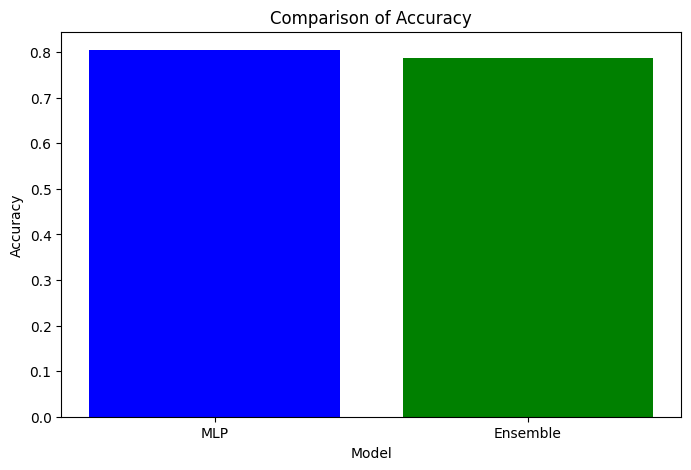

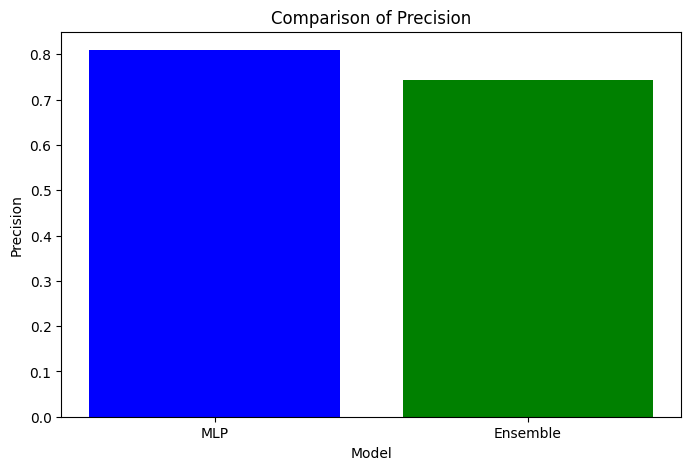

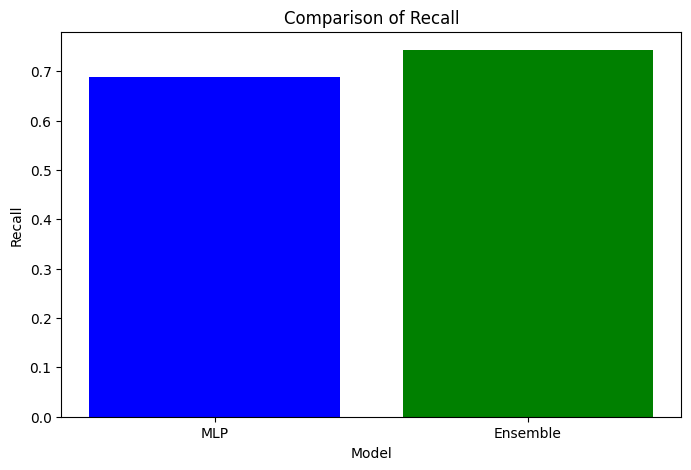

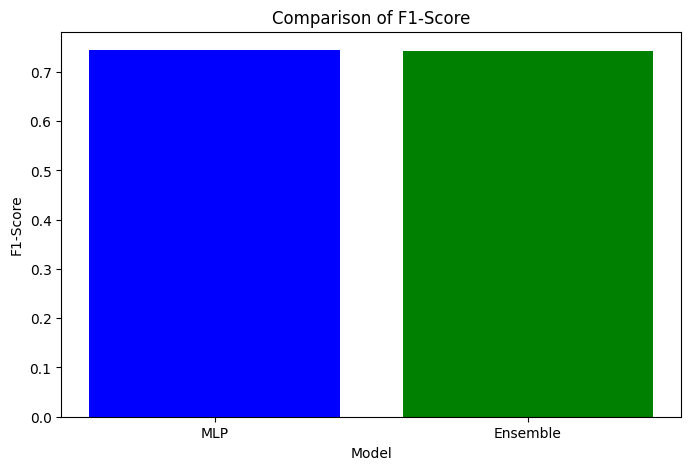

In [199]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt




def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Performance Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)
    return {"Model": model_name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}

# مقارنة النماذج
results = []
results.append(evaluate_model(y_test, mlp_predictions, "MLP"))
results.append(evaluate_model(y_test, y_pred, "Ensemble"))

# تحويل النتائج إلى جدول
results_df = pd.DataFrame(results)

# عرض النتائج
print("Summary of Results:")
print(results_df)

# رسم المقارنة بين النماذج
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["Model"], results_df[metric], color=['blue', 'green', 'orange'])
    plt.title(f"Comparison of {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.show()


In [200]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# مقارنة النماذج
results = []
results.append(evaluate_model(y_test, mlp_predictions, "MLP"))
# Use y_pred (Random Forest predictions) as ensemble_predictions
results.append(evaluate_model(y_test, y_pred, "Ensemble")) # Changed this line

# تحويل النتائج إلى DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# تحديد الأفضل والأسوأ لكل مقياس
best_models = results_df.idxmax(axis=0)
worst_models = results_df.idxmin(axis=0)

# عرض النتائج
print("Comparison Results:")
print(results_df)

print("\nBest Models by Metric:")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    best_model = results_df.iloc[best_models[metric]]["Model"]
    print(f"Best {metric}: {best_model} ({results_df[metric].max():.4f})")

print("\nWorst Models by Metric:")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    worst_model = results_df.iloc[worst_models[metric]]["Model"]
    print(f"Worst {metric}: {worst_model} ({results_df[metric].min():.4f})")

Comparison Results:
      Model  Accuracy  Precision    Recall  F1-Score
0       MLP  0.804469   0.809524  0.689189  0.744526
1  Ensemble  0.787709   0.743243  0.743243  0.743243

Best Models by Metric:
Best Accuracy: MLP (0.8045)
Best Precision: MLP (0.8095)
Best Recall: Ensemble (0.7432)
Best F1-Score: MLP (0.7445)

Worst Models by Metric:
Worst Accuracy: Ensemble (0.7877)
Worst Precision: Ensemble (0.7432)
Worst Recall: MLP (0.6892)
Worst F1-Score: Ensemble (0.7432)


In [201]:
# Reset the index of y_train before fitting the model
y_train = y_train.reset_index(drop=True)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

mlp_model = Sequential()

# Adjust the input shape to match the number of features in your data
mlp_model.add(Dense(64, input_dim=10, activation='relu'))  # input_dim=10 for 10 features
mlp_model.add(Dense(32, activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile the model
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Compile the MLP model with Adam optimizer, binary cross-entropy loss, and accuracy metric
mlp_model.compile(
    optimizer='adam',                # Specify optimizer
    loss='binary_crossentropy',      # Use binary cross-entropy for binary classification
    metrics=['accuracy']             # Use accuracy metric
)

# Train the MLP model
mlp_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,            # Use 20% of the data for validation
    class_weight={0: 1, 1: 2}        # Handle class imbalance by assigning weights
)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6714 - loss: 0.9309 - val_accuracy: 0.8182 - val_loss: 0.6087
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7846 - loss: 0.8571 - val_accuracy: 0.8042 - val_loss: 0.5620
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7536 - loss: 0.8212 - val_accuracy: 0.8042 - val_loss: 0.5184
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7733 - loss: 0.7332 - val_accuracy: 0.7972 - val_loss: 0.5023
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7299 - loss: 0.7550 - val_accuracy: 0.8112 - val_loss: 0.4916
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7978 - loss: 0.6797 - val_accuracy: 0.8182 - val_loss: 0.4741
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7527 - loss: 0.7121 - val_accuracy: 0.8182 - val_loss: 0.4679
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7630 - loss: 0.6973 - val_accuracy: 0.8182 - val_loss: 0.4593
Ep

In [202]:
# Before calling mlp_model.fit
y_train = y_train.reset_index(drop=True)

# ... your existing code ...

# Train the MLP model
mlp_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8211 - loss: 0.4278 - val_accuracy: 0.8392 - val_loss: 0.3895
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8192 - loss: 0.4332 - val_accuracy: 0.8322 - val_loss: 0.3881
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8105 - loss: 0.4443 - val_accuracy: 0.8392 - val_loss: 0.3955
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8122 - loss: 0.4351 - val_accuracy: 0.8392 - val_loss: 0.3882
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8191 - loss: 0.4171 - val_accuracy: 0.8392 - val_loss: 0.3928
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8315 - loss: 0.4062 - val_accuracy: 0.8392 - val_loss: 0.3882
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7970 - loss: 0.4548 - val_accuracy: 0.8392 - val_loss: 0.3901
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8340 - loss: 0.4012 - val_accuracy: 0.8322 - val_loss:

<ipython-input-203-a287b0890151>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Performance Metrics for MLP:
Accuracy: 0.4358
Precision: 0.4118
Recall: 0.8514
F1-Score: 0.5551
AUC-ROC: 0.4971

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.14      0.23       105
           1       0.41      0.85      0.56        74

    accuracy                           0.44       179
   macro avg       0.49      0.50      0.39       179
weighted avg       0.51      0.44      0.36       179


Confusion Matrix:


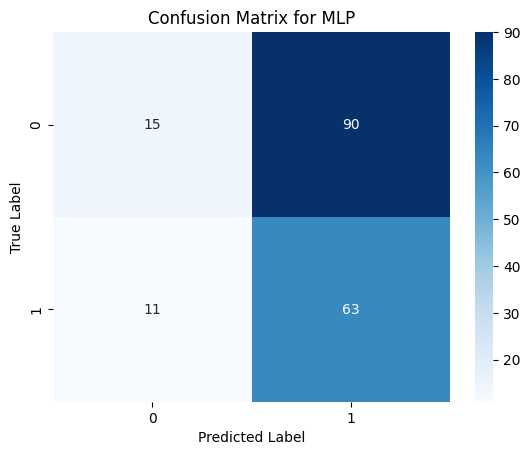

--------------------------------------------------
Performance Metrics for Ensemble (Random Forest):
Accuracy: 0.8045
Precision: 0.7826
Recall: 0.7297
F1-Score: 0.7552
AUC-ROC: 0.7934

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:


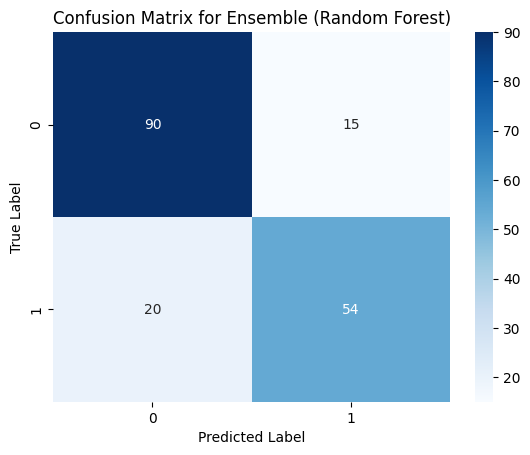

--------------------------------------------------


In [203]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل البيانات
data = pd.read_csv('titanic_train.csv')


data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

# 2. التعامل مع القيم المفقودة:
data['Age'].fillna(data['Age'].mean(), inplace=True)

# 3. إزالة الأعمدة غير الضرورية:
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# تقسيم البيانات إلى مجموعات تدريب واختبار
X = data.drop('Survived', axis=1)
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# توسيع نطاق البيانات
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1. Multi-Layer Perceptron (MLP)
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])






# 2. Ensemble Learning Technique (Random Forest)
ensemble_model = RandomForestClassifier(n_estimators=100, random_state=42)
ensemble_model.fit(X_train, y_train)


# التقييم
def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    if model_name == "MLP":
        y_pred = (y_pred > 0.5).astype(int)
    print(f"Performance Metrics for {model_name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    print("-" * 50)

# تقييم نموذج MLP ( MLP model)
evaluate_model(mlp_model, "MLP")
#تقييم  (Evaluate Ensemble model)
evaluate_model(ensemble_model, "Ensemble (Random Forest)")

